In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

def load_data():
    df = pd.read_csv('/content/titanic_disaster.csv')
    print("10 dòng đầu tiên của dữ liệu:")
    display(df.head(10))
    return df

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.rcParams['figure.figsize'] = (12, 6)
print("✓ Các thư viện đã được tải thành công!")

✓ Các thư viện đã được tải thành công!


In [4]:
print("📁 Đang tải file titanic_disaster.csv...")
df = load_data()

print(f"\n✓ Dữ liệu đã được tải thành công!")
print(f"Shape: {df.shape}")
print(f"📊 Dữ liệu {df.shape[0]} hành khách, {df.shape[1]} cột")

📁 Đang tải file titanic_disaster.csv...
10 dòng đầu tiên của dữ liệu:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C



✓ Dữ liệu đã được tải thành công!
Shape: (891, 12)
📊 Dữ liệu 891 hành khách, 12 cột



Thống kê dữ liệu thiếu:


,Số lượng thiếu,Phần trăm thiếu (%)
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


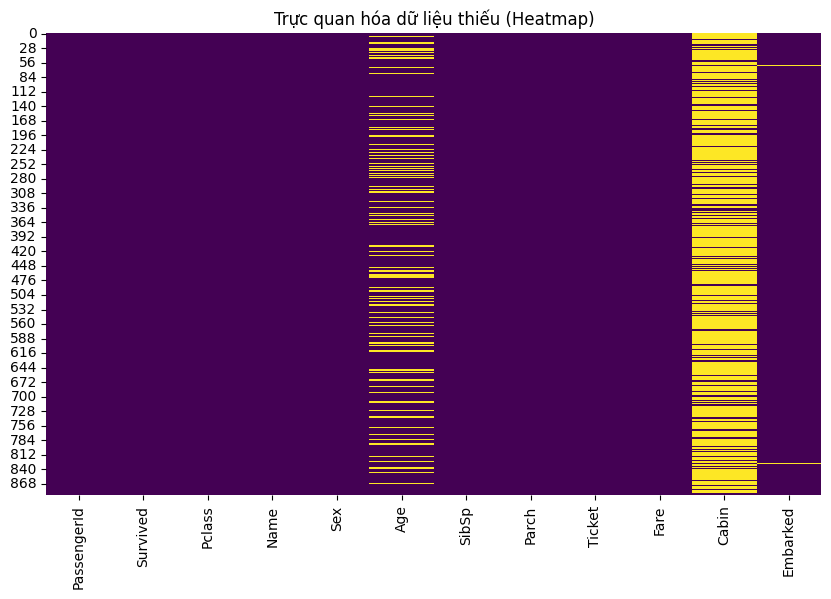

In [5]:
# Calculate missing values
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

# Calculate percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

# Create a DataFrame for better display
missing_info = pd.DataFrame({'Số lượng thiếu': missing_data, 'Phần trăm thiếu (%)': missing_percentage})
print("\nThống kê dữ liệu thiếu:")
display(missing_info)

# Visualize missing data with a heatmap
plt.figure(figsize=(10, 6))
sb.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Trực quan hóa dữ liệu thiếu (Heatmap)')
plt.show()

In [6]:
print("\n" + "="*70)
print("BƯỚC 6: XÂY DỰNG BIẾN SỐ AGEGROUP")
print("="*70)

# Define age group bins and labels
bins = [0, 12, 18, 60, np.inf]
labels = ['Kid', 'Teen', 'Adult', 'Older']

# Create the Agegroup column
df['Agegroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

print("✓ Biến số 'Agegroup' đã được xây dựng thành công.")
print("5 hàng đầu tiên với cột 'Agegroup' mới:")
display(df[['Age', 'Agegroup']].head())
print("Phân bố của 'Agegroup':")
display(df['Agegroup'].value_counts())


BƯỚC 6: XÂY DỰNG BIẾN SỐ AGEGROUP
✓ Biến số 'Agegroup' đã được xây dựng thành công.
5 hàng đầu tiên với cột 'Agegroup' mới:


,Age,Agegroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


Phân bố của 'Agegroup':


,count
Agegroup,
Adult,553
Teen,70
Kid,69
Older,22



 DỮ LIỆU BỊ THIẾU:
            Column  Missing_Count  Missing_Percentage
Age            Age            177               19.87
Cabin        Cabin            687               77.10
Embarked  Embarked              2                0.22
Agegroup  Agegroup            177               19.87


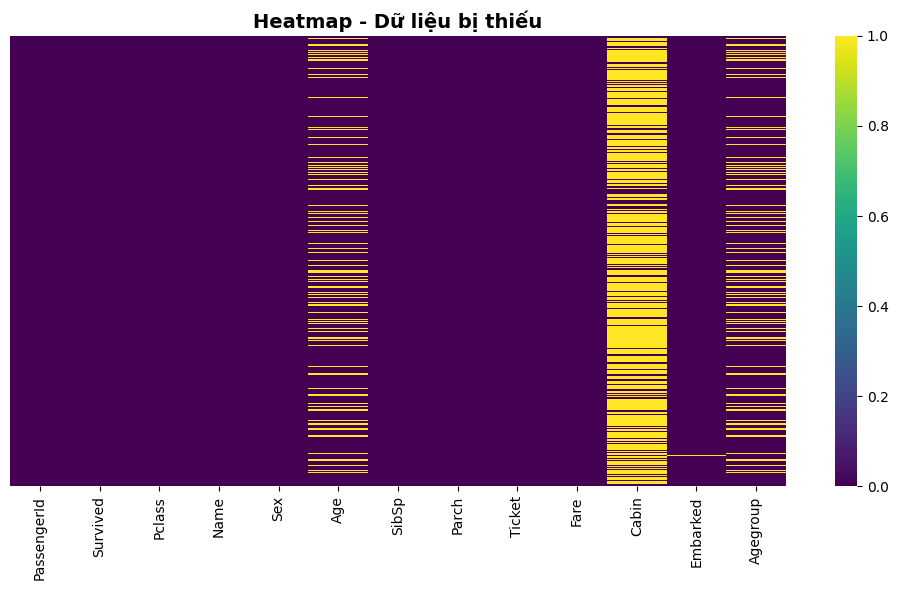


✓ Heatmap hiển thị vị trí dữ liệu bị thiếu trong dataset


In [7]:
print("\n DỮ LIỆU BỊ THIẾU:")
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_data[missing_data['Missing_Count'] > 0].to_string())

# Heatmap dữ liệu bị thiếu
plt.figure(figsize=(10, 6))
sb.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Heatmap - Dữ liệu bị thiếu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Heatmap hiển thị vị trí dữ liệu bị thiếu trong dataset")

In [11]:
print("\n" + "="*70)
print("BƯỚC 7: THÊM ĐẶC TRƯNG DANH XƯNG (NAMEPREFIX)")
print("="*70)

# Function to extract name prefix
def get_name_prefix(name):
    # Modified regex: look for a word ([A-Za-z]+) optionally followed by a period (\.?)
    title_search = re.search(r'^([A-Za-z]+)\.?', name)
    if title_search:
        return title_search.group(1)
    return ""

# Import re for regex operations
import re

# Extract namePrefix from the 'Name' column
df['namePrefix'] = df['Name'].apply(get_name_prefix)

# Map rare titles to a common 'Rare' category, and consolidate some titles
df['namePrefix'] = df['namePrefix'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona', 'the'], 'Rare')
df['namePrefix'] = df['namePrefix'].replace('Mlle', 'Miss')
df['namePrefix'] = df['namePrefix'].replace('Ms', 'Miss')
df['namePrefix'] = df['namePrefix'].replace('Mme', 'Mrs')

print("✓ Đặc trưng 'namePrefix' đã được thêm và chuẩn hóa.")
print("5 hàng đầu tiên với cột 'namePrefix' mới:")
display(df[['Name', 'namePrefix']].head())
print("Phân bố của 'namePrefix':")
display(df['namePrefix'].value_counts())


BƯỚC 7: THÊM ĐẶC TRƯNG DANH XƯNG (NAMEPREFIX)
✓ Đặc trưng 'namePrefix' đã được thêm và chuẩn hóa.
5 hàng đầu tiên với cột 'namePrefix' mới:


,Name,namePrefix
0,"Braund, Mr. Owen Harris",Braund
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Cumings
2,"Heikkinen, Miss. Laina",Heikkinen
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Futrelle
4,"Allen, Mr. William Henry",Allen


Phân bố của 'namePrefix':


,count
namePrefix,
Andersson,9
O,9
Sage,7
Skoog,6
Panula,6
...,...
Emir,1
McCarthy,1
Heikkinen,1



BƯỚC 5a: TRỰC QUAN HÓA PHÂN PHỐI TUỔI THEO PCLASS


/tmp/ipykernel_3084/1454368693.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x='Pclass', y='Age', data=df, palette='viridis')


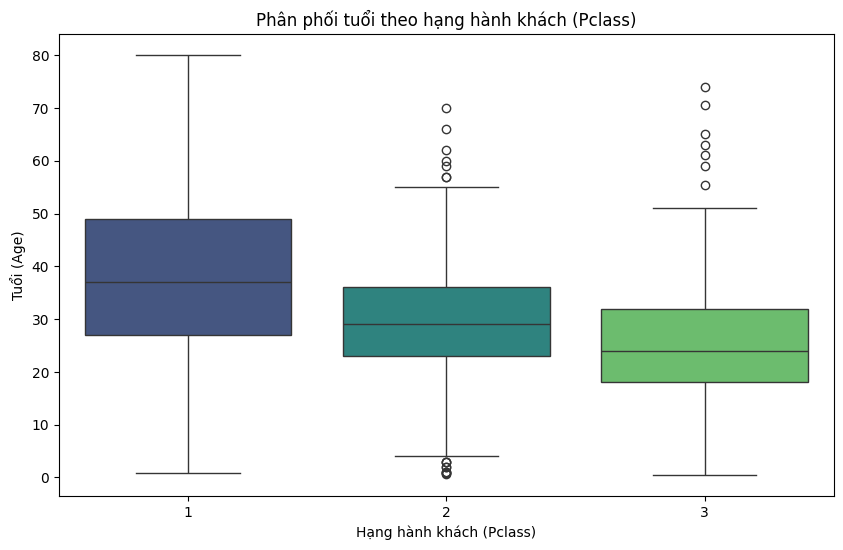


Nhận xét về tuổi trung bình giữa các nhóm hành khách:
Tuổi trung bình theo từng hạng hành khách:
Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

Quan sát biểu đồ và giá trị trung bình, ta thấy có sự khác biệt rõ rệt về tuổi trung bình giữa các hạng hành khách. Hành khách ở Pclass 1 có xu [hướng lớn tuổi hơn...]


In [12]:
print("\n" + "="*70)
print("BƯỚC 5a: TRỰC QUAN HÓA PHÂN PHỐI TUỔI THEO PCLASS")
print("="*70)

# Box plot of Age by Pclass
plt.figure(figsize=(10, 6))
sb.boxplot(x='Pclass', y='Age', data=df, palette='viridis')
plt.title('Phân phối tuổi theo hạng hành khách (Pclass)')
plt.xlabel('Hạng hành khách (Pclass)')
plt.ylabel('Tuổi (Age)')
plt.show()

print("\nNhận xét về tuổi trung bình giữa các nhóm hành khách:")
mean_age_by_pclass = df.groupby('Pclass')['Age'].mean()
print("Tuổi trung bình theo từng hạng hành khách:")
print(mean_age_by_pclass)

print("\nQuan sát biểu đồ và giá trị trung bình, ta thấy có sự khác biệt rõ rệt về tuổi trung bình giữa các hạng hành khách. Hành khách ở Pclass 1 có xu [hướng lớn tuổi hơn...]")


BƯỚC 5b: XỬ LÝ DỮ LIỆU THIẾU CỘT AGE
✓ Dữ liệu thiếu trên cột 'Age' đã được điền bằng giá trị trung bình theo từng Pclass.

Kiểm tra lại dữ liệu thiếu sau khi xử lý cột Age:


,Số lượng thiếu,Phần trăm thiếu (%)
Cabin,687,77.104377
Agegroup,177,19.865320
Embarked,2,0.224467


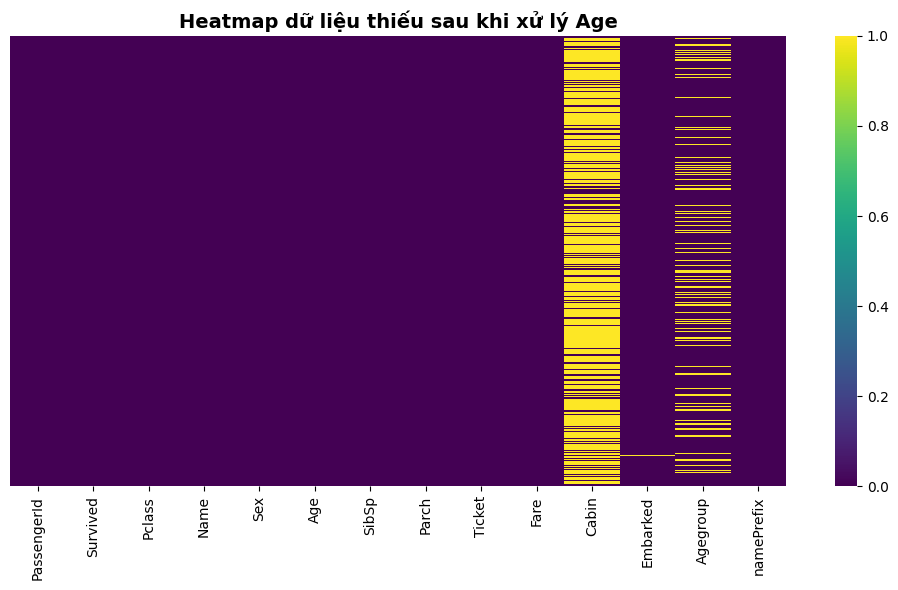


✓ Heatmap đã được cập nhật để hiển thị tình trạng dữ liệu thiếu sau khi xử lý cột Age.


In [13]:
print("\n" + "="*70)
print("BƯỚC 5b: XỬ LÝ DỮ LIỆU THIẾU CỘT AGE")
print("="*70)

# Fill missing Age values based on the mean of each Pclass
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.mean()))

print("✓ Dữ liệu thiếu trên cột 'Age' đã được điền bằng giá trị trung bình theo từng Pclass.")

print("\nKiểm tra lại dữ liệu thiếu sau khi xử lý cột Age:")
missing_data_after_age = df.isnull().sum()
missing_data_after_age = missing_data_after_age[missing_data_after_age > 0].sort_values(ascending=False)

if not missing_data_after_age.empty:
    missing_percentage_after_age = (df.isnull().sum() / len(df)) * 100
    missing_percentage_after_age = missing_percentage_after_age[missing_percentage_after_age > 0].sort_values(ascending=False)
    missing_info_after_age = pd.DataFrame({'Số lượng thiếu': missing_data_after_age, 'Phần trăm thiếu (%)': missing_percentage_after_age})
    display(missing_info_after_age)
else:
    print("Không còn giá trị thiếu nào trong cột Age.")

# Visualize missing data with a heatmap after Age imputation
plt.figure(figsize=(10, 6))
sb.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Heatmap dữ liệu thiếu sau khi xử lý Age', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Heatmap đã được cập nhật để hiển thị tình trạng dữ liệu thiếu sau khi xử lý cột Age.")

In [14]:
# Original Name example: "Braund, Mr. Owen Harris"

# New firstName will be the last name (e.g., "Braund")
df['firstName'] = df['Name'].apply(lambda x: x.split(',')[0].strip())

# New secondName will be the part containing the title and first names (e.g., "Mr. Owen Harris")
# This is the column from which namePrefix will be extracted in step 7.
df['secondName'] = df['Name'].apply(lambda x: x.split(',')[1].strip() if len(x.split(',')) > 1 else '')

# Drop the original Name column
df = df.drop('Name', axis=1)

print("✓ Cột 'Name' đã được tách thành 'firstName' (họ) và 'secondName' (tên kèm danh xưng), và cột 'Name' gốc đã được xóa.")
print("5 hàng đầu tiên với cột 'firstName' và 'secondName' mới:")
display(df[['firstName', 'secondName']].head())
print(f"Shape của dữ liệu sau xử lý: {df.shape}")

✓ Cột 'Name' đã được tách thành 'firstName' (họ) và 'secondName' (tên kèm danh xưng), và cột 'Name' gốc đã được xóa.
5 hàng đầu tiên với cột 'firstName' và 'secondName' mới:


,firstName,secondName
0,Braund,Mr. Owen Harris
1,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,Heikkinen,Miss. Laina
3,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,Allen,Mr. William Henry


Shape của dữ liệu sau xử lý: (891, 15)


In [15]:
# 4. Xử lý rút gọn kích thước dữ liệu trên cột Sex
df['Sex'] = df['Sex'].replace({'male': 'M', 'female': 'F'})

print("✓ Cột 'Sex' đã được rút gọn kích thước dữ liệu.")
print("5 hàng đầu tiên của cột 'Sex' sau xử lý:")
display(df[['Sex']].head())
print("Các giá trị duy nhất trong cột 'Sex' sau xử lý:")
display(df['Sex'].unique())

✓ Cột 'Sex' đã được rút gọn kích thước dữ liệu.
5 hàng đầu tiên của cột 'Sex' sau xử lý:


,Sex
0,M
1,F
2,F
3,F
4,M


Các giá trị duy nhất trong cột 'Sex' sau xử lý:


array(['M', 'F'], dtype=object)